In [1]:
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [2]:
local_id = 3
train_data = np.load(f'../data/local_data_{local_id}.npz')
x = train_data['x']
y = train_data['y']

In [3]:
test_data = np.load('../data/test_data.npz')
x_test = test_data['x_test']
y_test = test_data['y_test']

In [4]:
def train_and_verify(local_model, local_data, epochs, x_test, y_test, save_name):
    print(local_model)

    history = local_model.fit(local_data[0], local_data[1], epochs=epochs, validation_data=(x_test, y_test))
    y_pred = local_model.predict(x_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    print(classification_report(y_test, y_pred_classes))

    plt.plot(history.history['accuracy'], label='Training accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    local_model.save(save_name)

c:\Users\juanj\OneDrive\Documentos\GitHub\ma3001b-federated-learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential, built=True>
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8825 - loss: 0.3858 - val_accuracy: 0.9588 - val_loss: 0.1381
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9642 - loss: 0.1155 - val_accuracy: 0.9730 - val_loss: 0.0889
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9775 - loss: 0.0714 - val_accuracy: 0.9757 - val_loss: 0.0770
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9827 - loss: 0.0535 - val_accuracy: 0.9771 - val_loss: 0.0666
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9858 - loss: 0.0412 - val_accuracy: 0.9782 - val_loss: 0.0728
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9902 - loss: 0.0290 - val_accuracy: 0.9818 - val_loss: 0.0590
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9927 - loss: 0.0245 - val_accuracy: 0.9752 - val_loss: 0.0847
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy:

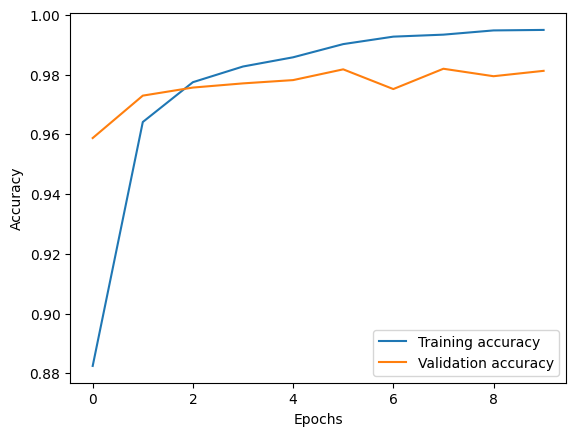

In [5]:
# Entrenamientos locales. Cada uno de estos deben hacerse en computadoras aparte.
from model import build
from tqdm import tqdm

local_model = build.build_it()
train_and_verify(local_model, (x, y), 10, x_test, y_test, f"../models/local_model_{local_id}.keras")